In [143]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
x, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [165]:
m1=LogisticRegression()
m1.fit(x,y)
coef_=-m1.coef_[0,0]/m1.coef_[0,1]
intercept_=-m1.intercept_/m1.coef_[0,1]
print(coef_,intercept_)

-148.89041745447122 [-297.9404898]


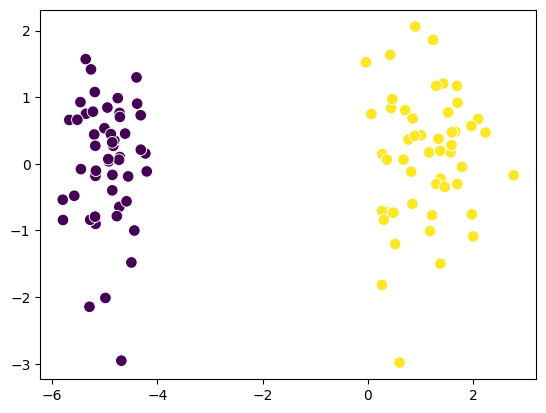

In [166]:
sns.scatterplot(x=x[:,0].flatten(),y=x[:,1].flatten(),c=y,cmap='viridis',s=70)
plt.show()

In [190]:
np.random.seed(10)
epochs=10000
lr=0.001
x_temp=np.insert(x,0,1,axis=1)
w=np.ones(x_temp.shape[1])
for i in range(epochs):
    idx=np.random.randint(0,100)
    y_hat=step(np.dot(x_temp[idx],w))
    w=w+lr*(y[idx]-y_hat)*x_temp[idx]
coef2_=-w[1]/w[2]
intercept2_=-w[0]/w[2]
print(coef2_,intercept2_)

-1.7101268035540416 -1.8291312776633721


In [168]:
def step(z):
    return 1 if z>0 else 0

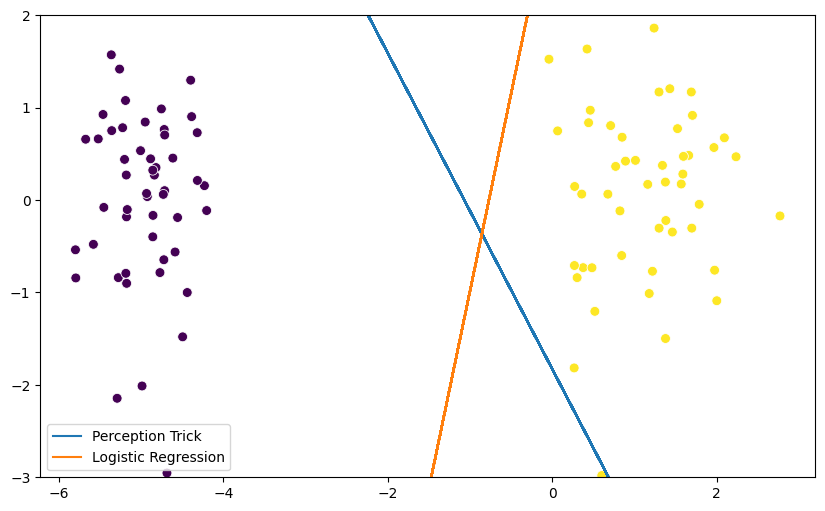

In [191]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=x[:,0].flatten(),y=x[:,1].flatten(),c=y,cmap='viridis',s=50)
plt.plot(x[:,0].flatten(),(coef2_*x[:,0]+intercept2_).flatten(),label='Perception Trick')
plt.plot(x[:,0].flatten(),(coef_*x[:,0]+intercept_).flatten(),label='Logistic Regression')
plt.legend()
plt.ylim(-3,2)
plt.show()

In [171]:
np.random.seed(4)
epochs=10000
lr=0.001
x_temp=np.insert(x,0,1,axis=1)
w=np.ones(x_temp.shape[1])
for i in range(epochs):
    idx=np.random.randint(0,100)
    y_hat=sigmoid(np.dot(x_temp[idx],w))
    w=w=lr*(y[idx]-y_hat)*x_temp[idx]
coef_=-w[1]/w[2]
intercept_=-w[0]/w[2]
print(coef_,intercept_)

4.274898624911307 3.2910380489703464


In [172]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

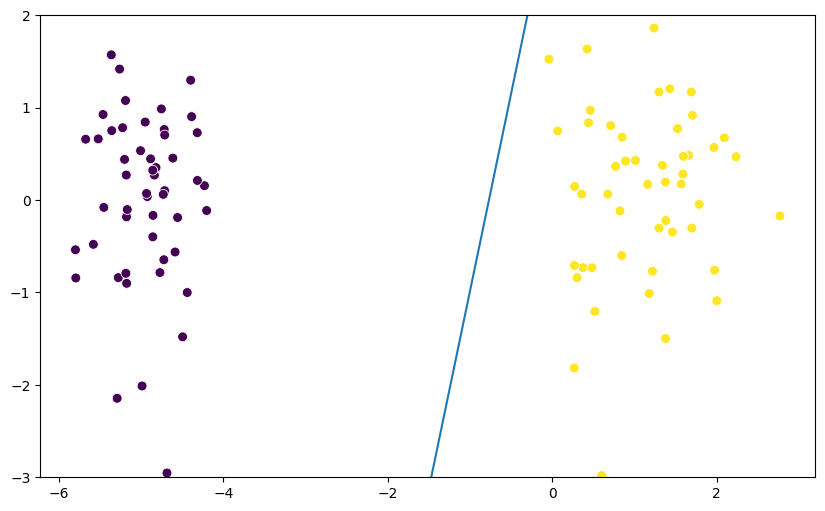

In [173]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=x[:,0].flatten(),y=x[:,1].flatten(),c=y,cmap='viridis',s=50)
plt.plot(np.linspace(-3,3,100).flatten(),(coef_*np.linspace(-3,3,100)+intercept_).flatten())
plt.ylim(-3,2)
plt.show()